# Review: correct_crater_with_labels.csv

Resumable review of the final 829-crater set (`data/raw/correct_crater_with_labels.csv`), a corrected subset of the original 1277-crater `new_test_set_labels.csv`.

Review progress already completed on this notebook's earlier run was carried forward for every crater that's still in the final set (529/829), so only the remaining ~300 need review here.

For each crater: agree with the current (area, degree) label, correct it, or flag it as a bad Robbins match entirely (wrong crater). Progress autosaves to `configs/correct_crater_with_labels_review.csv` on every action — stop and re-run this notebook anytime to resume.

In [ ]:
import sys
sys.path.insert(0, "../src")

from eval import review_labels as R

LABELS_CSV = "../configs/correct_crater_with_labels.csv"
IMGS_DIR = "../data/raw/new_test_set_crops_wide"

store = R.ReviewStore(LABELS_CSV)
done, total = store.progress()
print(f"resuming: {done}/{total} already reviewed")

In [2]:
_ = R.launch_reviewer(store, imgs_dir=IMGS_DIR)

## When done: export the reviewed, corrected set

Applies your corrections, drops anything flagged as a bad match, writes `configs/new_test_set_labels_final.csv`.

In [ ]:
out = R.export_reviewed(store, name="correct_crater_with_labels_final.csv")
print(f"wrote {out}")

import pandas as pd
final = pd.read_csv(out)
print(f"{len(final)} craters kept")
print(final["degree"].value_counts())

## Full audit: original vs. corrected degree, for every crater

Keeps all 829 craters (including anything flagged as a bad match) and all original columns from `correct_crater_with_labels.csv`, alongside the review state — so you can see, per crater, the degree Robbins/the source signed off on vs. the one you corrected it to. Writes `configs/correct_crater_with_labels_audit.csv`.

In [8]:
audit = store.merged().rename(columns={"area": "original_area", "degree": "original_degree"})

# resolved value: correction if one was made, else the original
audit["final_area"] = audit["corrected_area"].where(audit["corrected_area"].fillna("") != "", audit["original_area"])
audit["final_degree"] = audit["corrected_degree"].where(audit["corrected_degree"].fillna("") != "", audit["original_degree"])

audit = audit[[
    "CRATER_ID", "lat", "lon", "diam_km", "source", "match_dist_km", "flagged_low_confidence_match",
    "original_area", "original_degree",
    "corrected_area", "corrected_degree",
    "final_area", "final_degree",
    "reviewed", "agrees", "flag_bad_match", "note",
]]

audit_out = "../configs/correct_crater_with_labels_audit.csv"
audit.to_csv(audit_out, index=False)
print(f"wrote {audit_out}  ({len(audit)} craters, {audit['reviewed'].sum()} reviewed)")
print(f"corrected degree differs from original: {(audit['original_degree'] != audit['final_degree']).sum()}")
audit.head()

wrote ../configs/correct_crater_with_labels_audit.csv  (829 craters, 829 reviewed)
corrected degree differs from original: 164


,CRATER_ID,lat,lon,diam_km,source,match_dist_km,flagged_low_confidence_match,original_area,original_degree,corrected_area,corrected_degree,final_area,final_degree,reviewed,agrees,flag_bad_match,note
0,02-1-004775,1.00666,235.617,3.71381,additional_hebrew_list,0.265571,False,highland,v-fr,NaN,NaN,highland,v-fr,True,True,False,NaN
1,02-1-013542,3.68587,266.289,1.05221,additional_hebrew_list,4.549190,True,highland,v-fr,highland,r-dr,highland,r-dr,True,False,False,NaN
2,02-1-020934,6.46050,264.106,1.85732,additional_hebrew_list,0.278240,False,highland,v-fr,NaN,NaN,highland,v-fr,True,True,False,NaN
3,02-1-037395,9.65033,268.642,1.21656,additional_hebrew_list,3.483343,True,highland,v-fr,highland,r-dr,highland,r-dr,True,False,False,NaN
4,02-1-041474,11.80110,181.263,1.61743,additional_hebrew_list,3.299431,True,highland,v-fr,highland,v-fr,highland,v-fr,True,False,True,NaN


## Sanity check: random examples by degree class

Grabs random craters from the exported final set and shows them side by side, grouped by degree (`v-fr`, `r-fr`, `r-dr`, `v-dr`) so the classes are easy to eyeball against each other. Re-run the cell to resample.

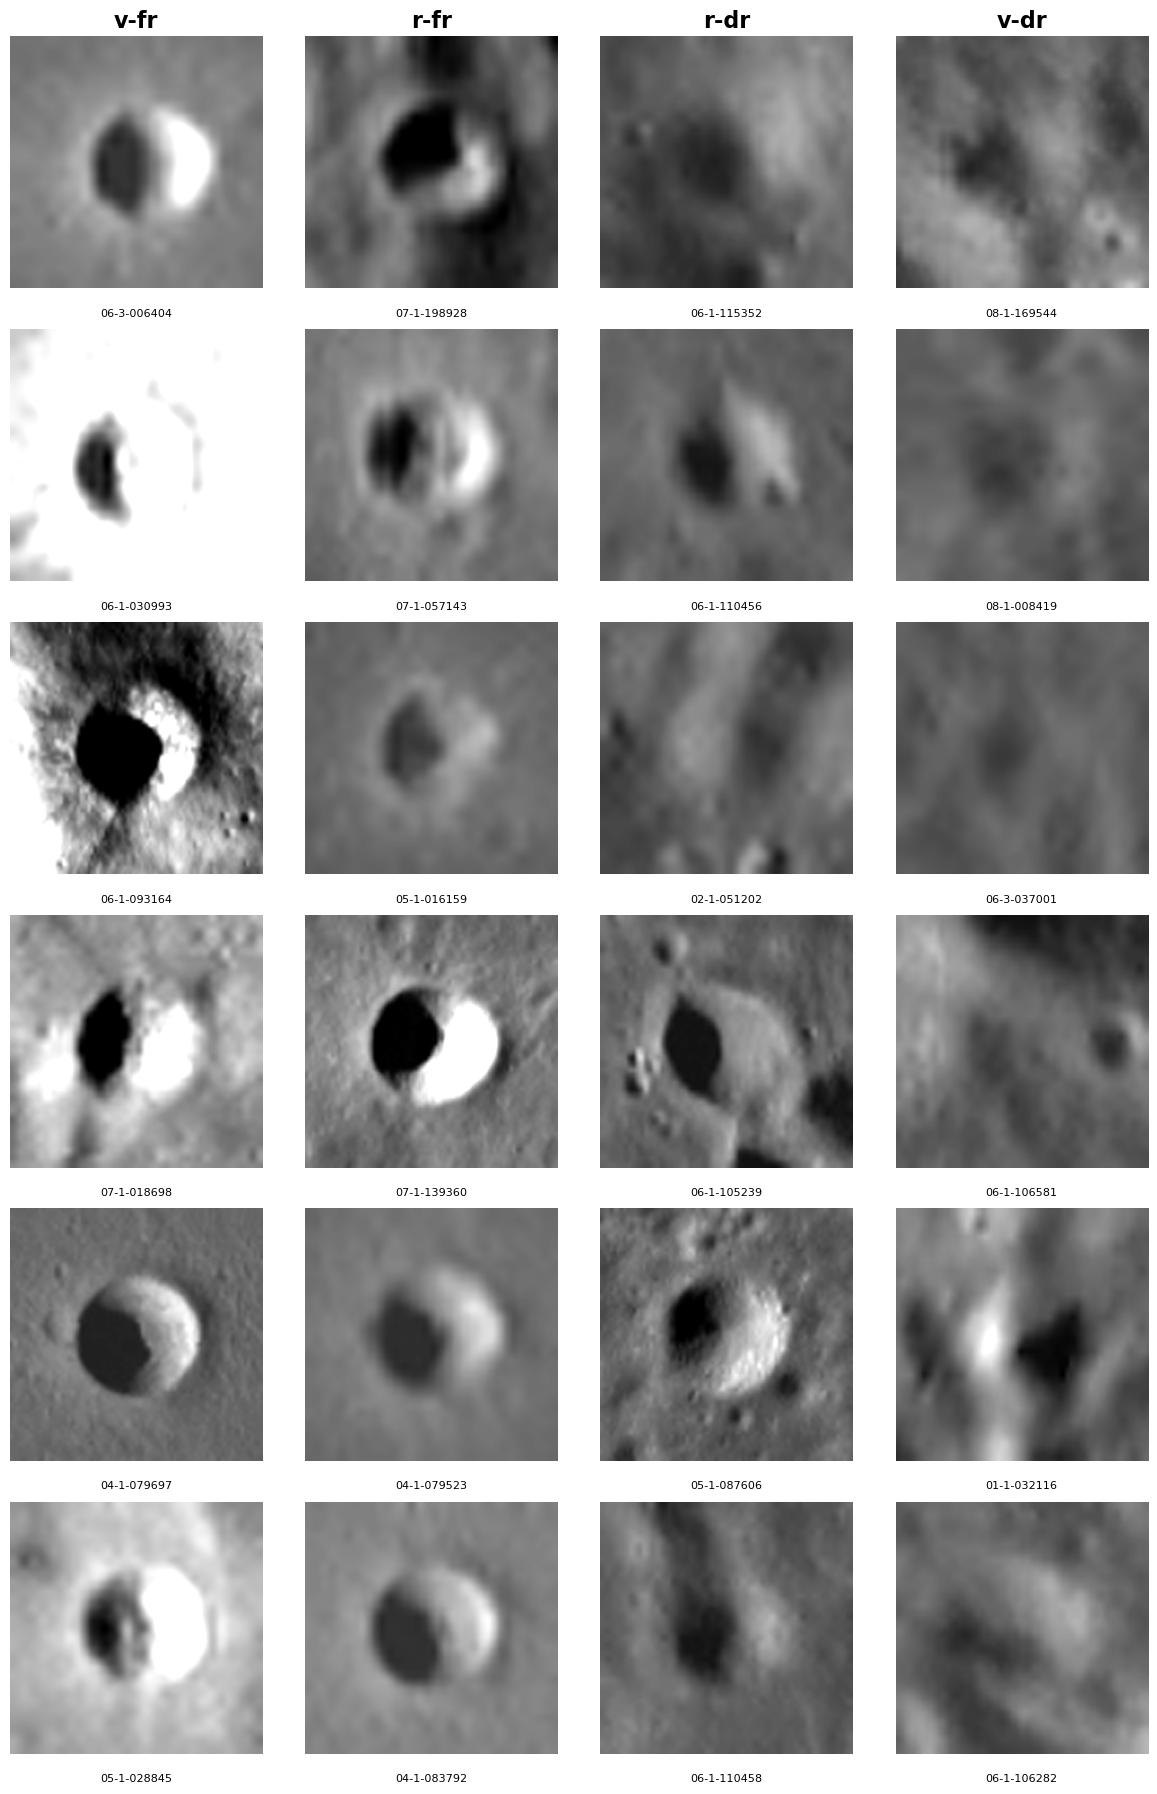

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

DEGREE_ORDER = ["v-fr", "r-fr", "r-dr", "v-dr"]
N_SAMPLES = 6

final = pd.read_csv(out, dtype={"CRATER_ID": str})

samples = {
    deg: final[final["degree"] == deg].sample(
        n=min(N_SAMPLES, (final["degree"] == deg).sum()), random_state=None
    )
    for deg in DEGREE_ORDER
}

fig, axes = plt.subplots(N_SAMPLES, len(DEGREE_ORDER), figsize=(3 * len(DEGREE_ORDER), 3 * N_SAMPLES))

for col, deg in enumerate(DEGREE_ORDER):
    rows = samples[deg].reset_index(drop=True)
    axes[0, col].set_title(deg, fontsize=16, fontweight="bold")
    for row in range(N_SAMPLES):
        ax = axes[row, col]
        ax.axis("off")
        if row >= len(rows):
            continue
        crater = rows.loc[row]
        img_path = Path(IMGS_DIR) / f"{crater['CRATER_ID']}.png"
        if img_path.exists():
            ax.imshow(mpimg.imread(img_path), cmap="gray")
        ax.text(0.5, -0.08, crater["CRATER_ID"], transform=ax.transAxes,
                ha="center", va="top", fontsize=8)

plt.tight_layout()
plt.show()